# 02 — ONNX Runtime

Benchmarks PP-LCNet_x1_0_doc_ori via ONNX Runtime.
Model was converted from Paddle 3.x PIR format using paddle2onnx (opset 17).

**Prerequisites:** `models/model.onnx` must exist (convert in setup or run paddle2onnx manually).

In [1]:
import sys
sys.path.insert(0, '..')

import time
from pathlib import Path

import numpy as np
import onnxruntime as ort
import pandas as pd
from tqdm import tqdm

from src.preprocess import load_and_preprocess

ONNX_PATH   = Path('../models/model.onnx')
DATASET_CSV = Path('../data/dataset.csv')
RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

print(f'OnnxRuntime version : {ort.__version__}')
print(f'ONNX model exists   : {ONNX_PATH.exists()}')
print(f'Available providers : {ort.get_available_providers()}')

OnnxRuntime version : 1.23.2
ONNX model exists   : True
Available providers : ['CoreMLExecutionProvider', 'AzureExecutionProvider', 'CPUExecutionProvider']


In [2]:
sess_options = ort.SessionOptions()
sess_options.intra_op_num_threads = 4
sess_options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL

session = ort.InferenceSession(
    str(ONNX_PATH),
    sess_options=sess_options,
    providers=['CPUExecutionProvider'],
)

input_name  = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
print(f'Input  : {input_name}  shape={session.get_inputs()[0].shape}')
print(f'Output : {output_name} shape={session.get_outputs()[0].shape}')

Input  : x  shape=['DynamicDimension.0', 3, 224, 224]
Output : fetch_name_0 shape=['DynamicDimension.0', 4]


In [3]:
def predict(image_path: str) -> tuple[int, float]:
    tensor = load_and_preprocess(image_path)
    outputs = session.run([output_name], {input_name: tensor})
    logits = outputs[0]
    pred_label = int(np.argmax(logits, axis=1)[0])
    confidence = float(np.max(logits))
    return pred_label, confidence

df = pd.read_csv(DATASET_CSV)

# Warm-up
_ = predict(df.iloc[0]['image_path'])
print('Warmed up.')

predictions, confidences, latencies = [], [], []

for row in tqdm(df.itertuples(), total=len(df), desc='ONNX Runtime inference'):
    t0 = time.perf_counter()
    pred, conf = predict(row.image_path)
    latencies.append((time.perf_counter() - t0) * 1000)
    predictions.append(pred)
    confidences.append(conf)

df['onnx_pred']       = predictions
df['onnx_conf']       = confidences
df['onnx_latency_ms'] = latencies
df.to_csv(RESULTS_DIR / 'onnx_results.csv', index=False)
print('Saved results/onnx_results.csv')

Warmed up.


ONNX Runtime inference:   0%|          | 0/552 [00:00<?, ?it/s]

ONNX Runtime inference:   1%|          | 4/552 [00:00<00:16, 33.11it/s]

ONNX Runtime inference:   1%|▏         | 8/552 [00:00<00:16, 33.23it/s]

ONNX Runtime inference:   2%|▏         | 12/552 [00:00<00:16, 32.48it/s]

...

ONNX Runtime inference:  98%|█████████▊| 541/552 [00:16<00:00, 32.01it/s]

ONNX Runtime inference:  99%|█████████▊| 545/552 [00:17<00:00, 31.57it/s]

ONNX Runtime inference:  99%|█████████▉| 549/552 [00:17<00:00, 31.01it/s]

ONNX Runtime inference: 100%|██████████| 552/552 [00:17<00:00, 31.90it/s]

Saved results/onnx_results.csv


In [4]:
def predict(image_path: str) -> tuple[int, float]:
    tensor = load_and_preprocess(image_path)
    outputs = session.run([output_name], {input_name: tensor})
    logits = outputs[0]
    pred_label = int(np.argmax(logits, axis=1)[0])
    confidence = float(np.max(logits))
    return pred_label, confidence

df = pd.read_csv(DATASET_CSV)

predictions, confidences, latencies = [], [], []

for row in tqdm(df.itertuples(), total=len(df), desc='ONNX Runtime inference'):
    t0 = time.perf_counter()
    pred, conf = predict(row.image_path)
    latencies.append((time.perf_counter() - t0) * 1000)
    predictions.append(pred)
    confidences.append(conf)

df['onnx_pred'] = predictions
df['onnx_conf'] = confidences
df['onnx_latency_ms'] = latencies
df.to_csv(RESULTS_DIR / 'onnx_results.csv', index=False)
print('Saved results/onnx_results.csv')

ONNX Runtime inference:   0%|          | 0/552 [00:00<?, ?it/s]

ONNX Runtime inference:   1%|          | 4/552 [00:00<00:15, 34.59it/s]

ONNX Runtime inference:   1%|▏         | 8/552 [00:00<00:15, 34.64it/s]

ONNX Runtime inference:   2%|▏         | 12/552 [00:00<00:16, 33.23it/s]

ONNX Runtime inference:   3%|▎         | 16/552 [00:00<00:16, 31.72it/s]

...

ONNX Runtime inference:  98%|█████████▊| 542/552 [00:17<00:00, 32.04it/s]

ONNX Runtime inference:  99%|█████████▉| 546/552 [00:17<00:00, 31.47it/s]

ONNX Runtime inference: 100%|█████████▉| 550/552 [00:17<00:00, 30.85it/s]

ONNX Runtime inference: 100%|██████████| 552/552 [00:17<00:00, 31.59it/s]

Saved results/onnx_results.csv


Accuracy:         0.8913
Avg latency:      31.53 ms
Throughput:       31.7 img/s

              precision    recall  f1-score   support

        0deg       0.89      0.91      0.90       138
       90deg       0.90      0.90      0.90       138
      180deg       0.88      0.87      0.88       138
      270deg       0.90      0.89      0.89       138

    accuracy                           0.89       552
   macro avg       0.89      0.89      0.89       552
weighted avg       0.89      0.89      0.89       552



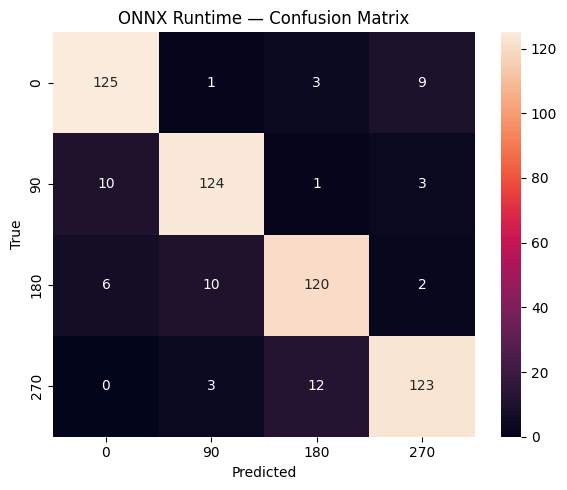

In [5]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy = (df['onnx_pred'] == df['label']).mean()
avg_latency = df['onnx_latency_ms'].mean()
throughput = 1000 / avg_latency

print(f'Accuracy:         {accuracy:.4f}')
print(f'Avg latency:      {avg_latency:.2f} ms')
print(f'Throughput:       {throughput:.1f} img/s')
print()
print(classification_report(df['label'], df['onnx_pred'],
                             target_names=['0deg','90deg','180deg','270deg']))

cm = confusion_matrix(df['label'], df['onnx_pred'])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', ax=ax,
            xticklabels=['0','90','180','270'],
            yticklabels=['0','90','180','270'])
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('ONNX Runtime — Confusion Matrix')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'onnx_confusion_matrix.png', dpi=150)
plt.show()